<h1 style="text-align:center; color:red;">Daily Challenge: Strategic Analysis of Superstore Performance
</h1>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

In [8]:
df = pd.read_excel('US Superstore data.xls')

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

df.info()
df.describe()
df.isnull().sum()

Dataset Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [10]:
# Duplicates
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

# Missing values
print(df.isnull().sum())

if 'Postal Code' in df.columns:
    df['Postal Code'] = df['Postal Code'].fillna(0)

Duplicate rows: 0
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [12]:
date_columns = ['Order Date', 'Ship Date']

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

print(df[date_columns].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [14]:
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

df[['Sales','Profit','Profit Margin','Order Year','Order Month']].head()

,Sales,Profit,Profit Margin,Order Year,Order Month
0,261.9600,41.9136,16.00,2016,11
1,731.9400,219.5820,30.00,2016,11
2,14.6200,6.8714,47.00,2016,6
3,957.5775,-383.0310,-40.00,2015,10
4,22.3680,2.5164,11.25,2015,10


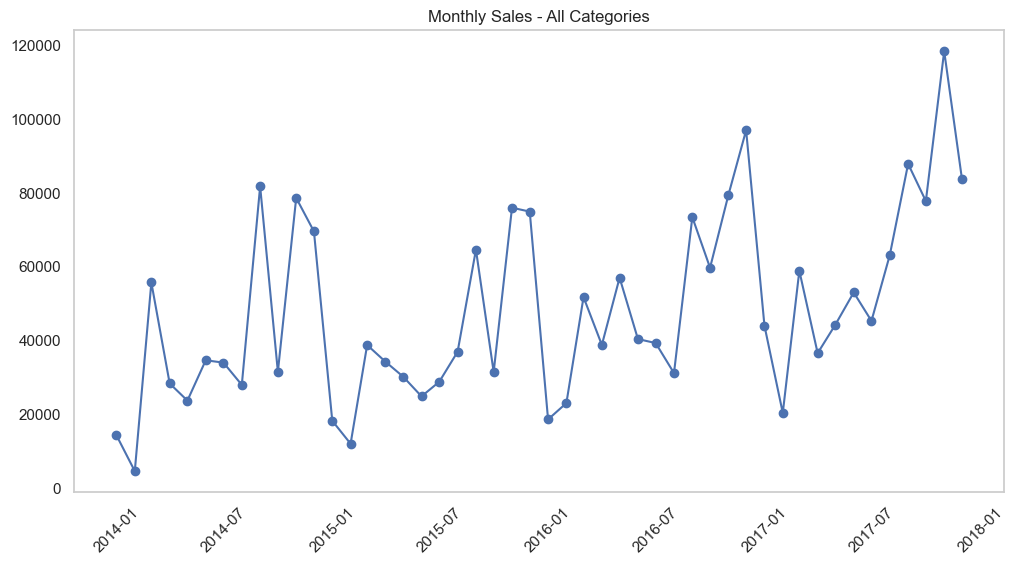

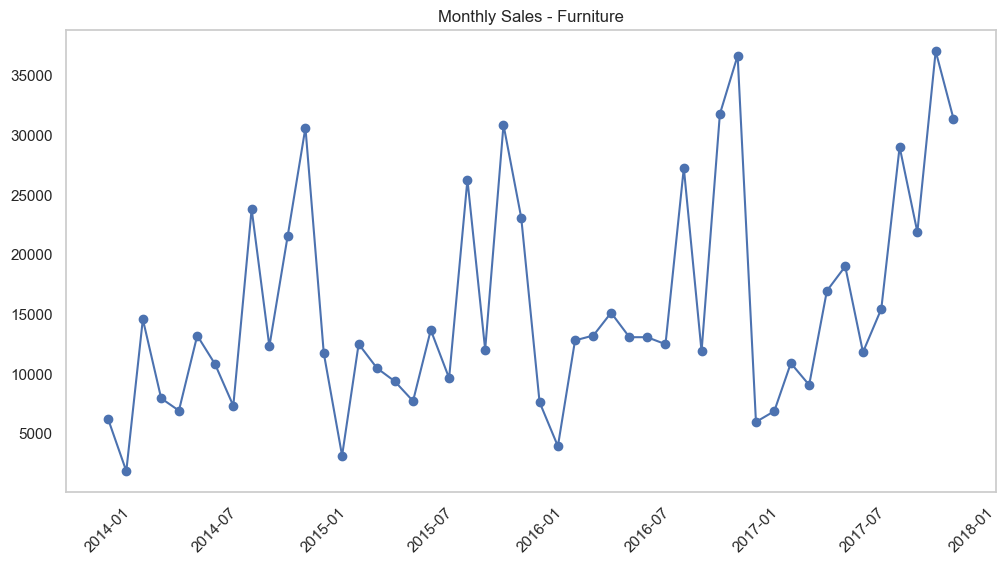

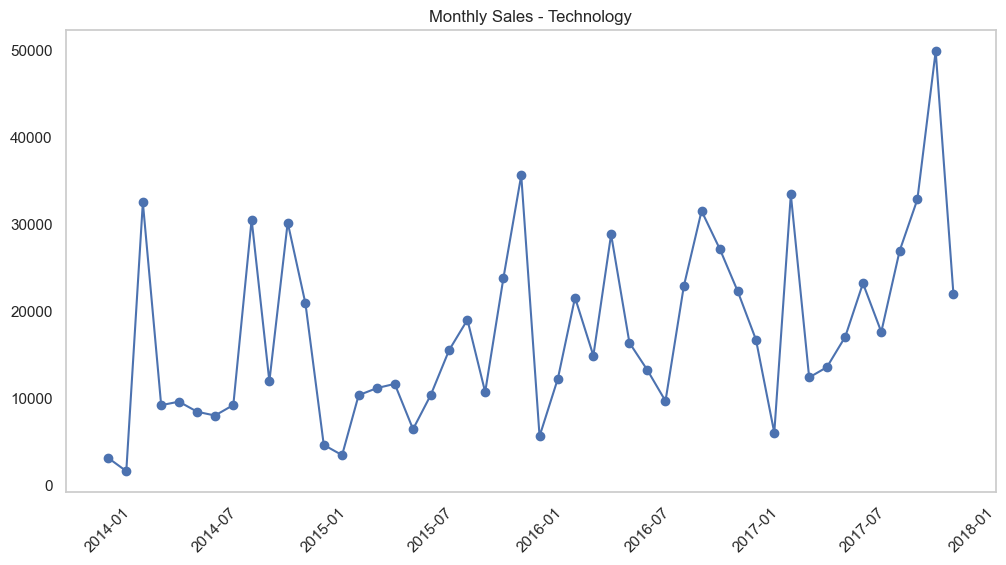

In [24]:
monthly_sales = df.groupby(['Order Month-Year','Category'])['Sales'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Order Month-Year'].dt.to_timestamp()

def plot_monthly_sales(category='All'):
    plt.figure(figsize=(12,6))

    if category == 'All':
        total = df.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(total.index.to_timestamp(), total.values, marker='o')
        plt.title('Monthly Sales - All Categories')
    else:
        data = monthly_sales[monthly_sales['Category']==category]
        plt.plot(data['Date'], data['Sales'], marker='o')
        plt.title(f'Monthly Sales - {category}')

    plt.xticks(rotation=45)
    plt.grid()
    plt.show()

categories = ['All'] + list(df['Category'].unique())
plot_monthly_sales('All')
plot_monthly_sales('Furniture')
plot_monthly_sales('Technology')

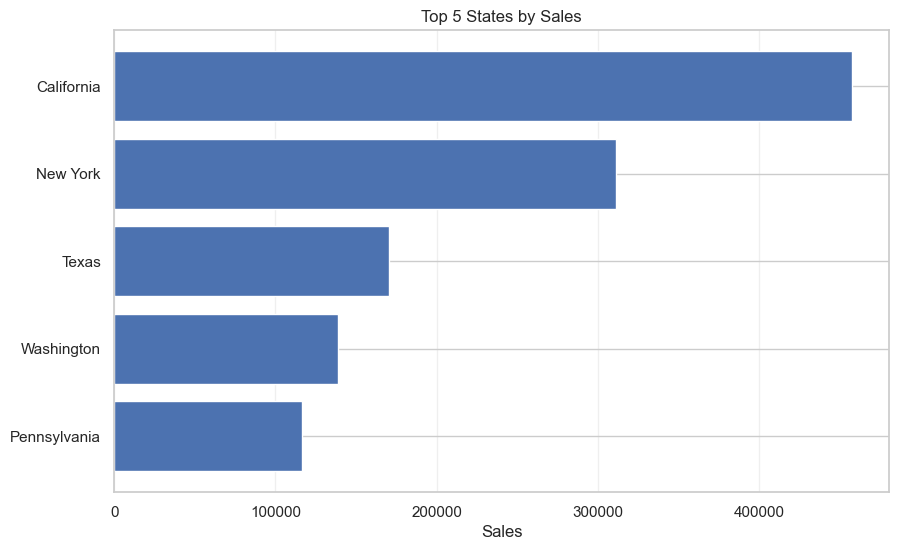

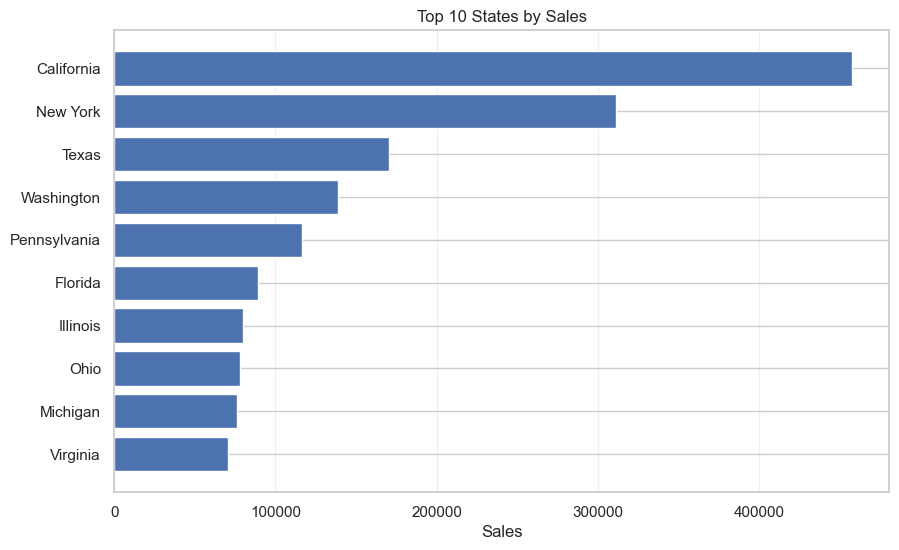

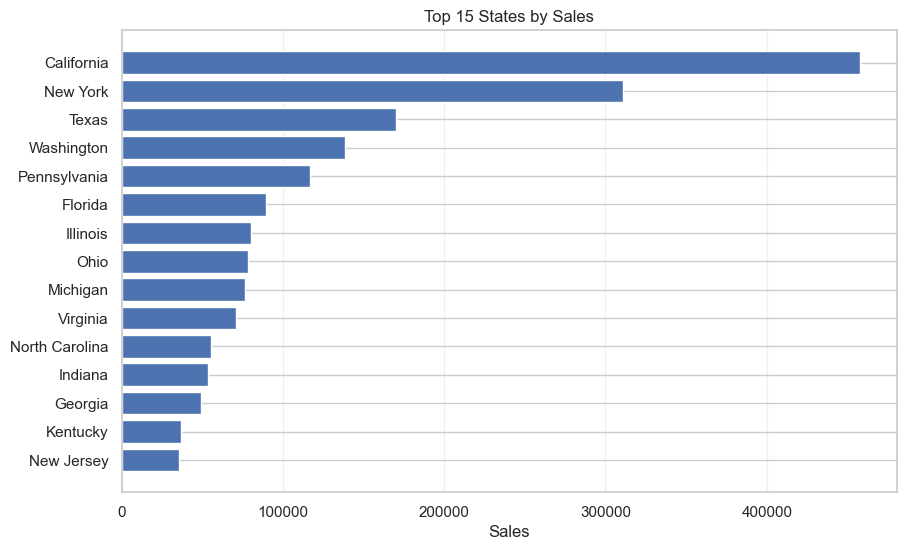

In [28]:
 
def plot_top_states(top_n):
    plt.figure(figsize=(10,6))

    top_states = state_sales.tail(top_n)

    plt.barh(top_states.index, top_states.values)
    plt.title(f"Top {top_n} States by Sales")
    plt.xlabel("Sales")

    plt.grid(axis='x', alpha=0.3)
    plt.show()
 
plot_top_states(5)
plot_top_states(10)
plot_top_states(15)

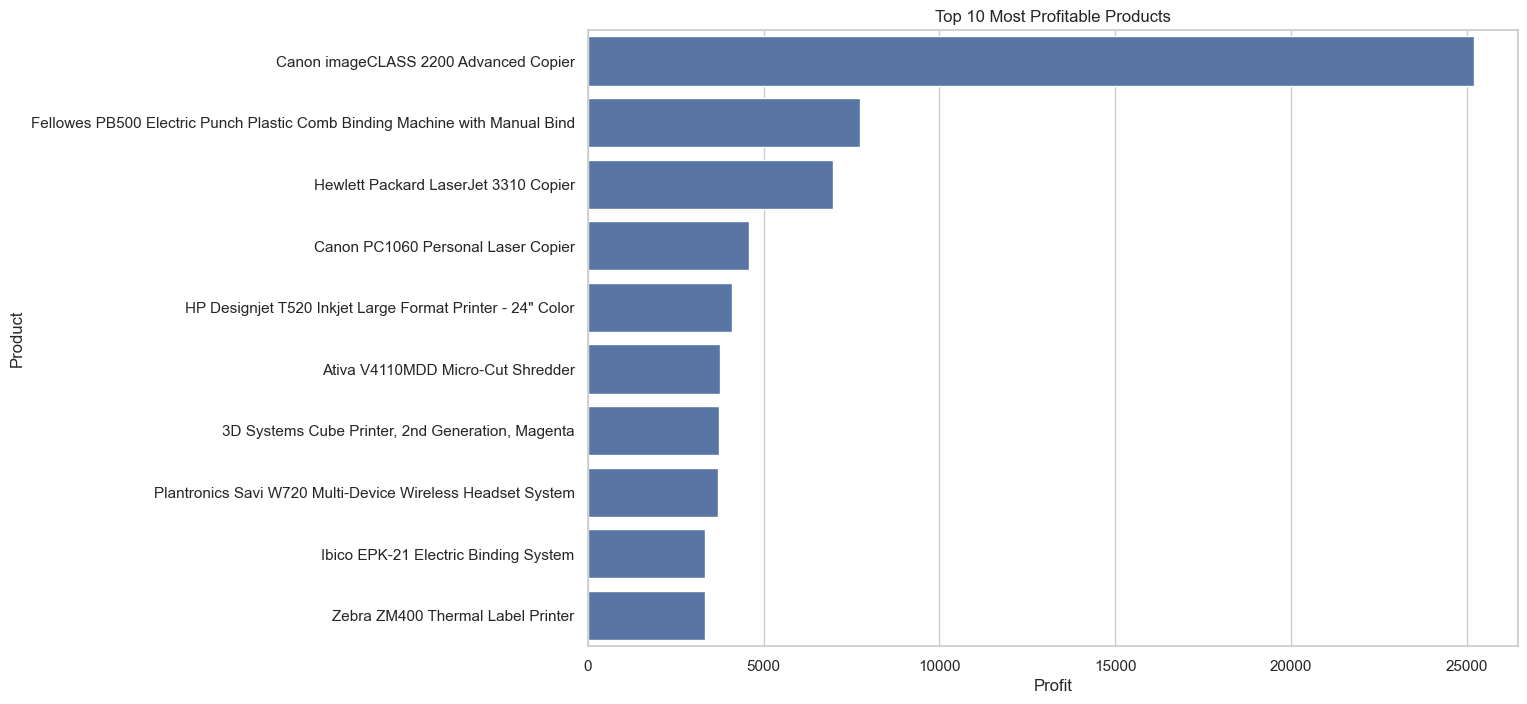

In [30]:
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,8))
sns.barplot(x=product_profit.values, y=product_profit.index)

plt.title("Top 10 Most Profitable Products")
plt.xlabel("Profit")
plt.ylabel("Product")

plt.show()

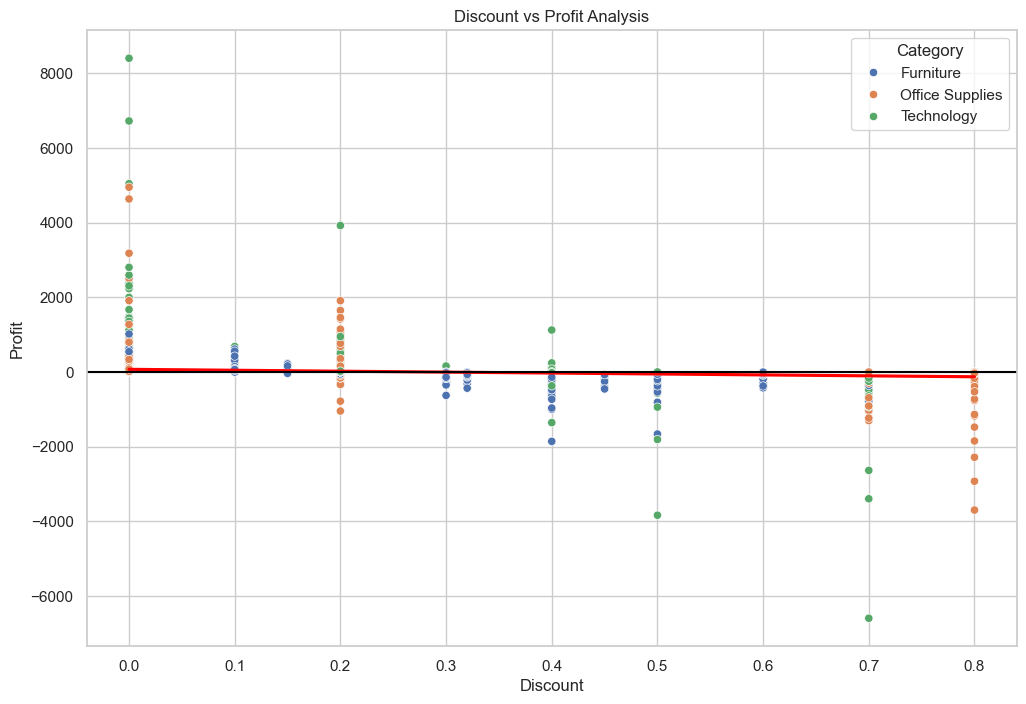

High discount transactions: 1393
Avg profit: -97.18309834888733
Loss rate: 96.76956209619526 %


In [32]:
plt.figure(figsize=(12,8))

sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category')
sns.regplot(data=df, x='Discount', y='Profit', scatter=False, color='red')

plt.axhline(0, color='black')
plt.title("Discount vs Profit Analysis")

plt.show()

# Insights
high_discount = df[df['Discount'] > 0.2]

print("High discount transactions:", len(high_discount))
print("Avg profit:", high_discount['Profit'].mean())
print("Loss rate:", (high_discount['Profit'] < 0).mean()*100, "%")

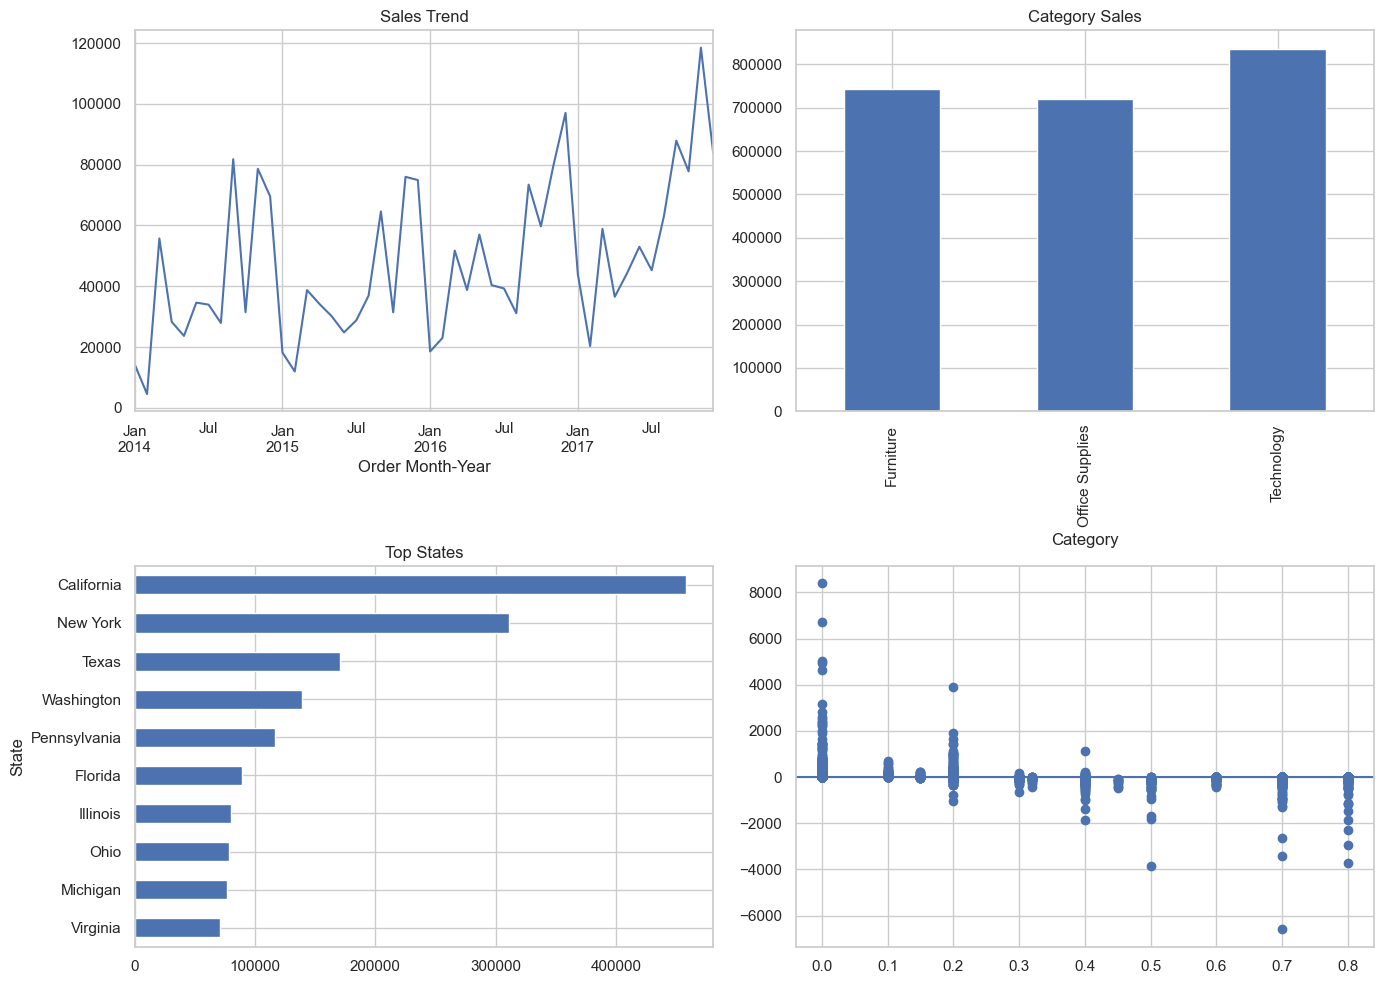

In [34]:
def dashboard():
    fig, axs = plt.subplots(2,2, figsize=(14,10))

    # Sales trend
    df.groupby('Order Month-Year')['Sales'].sum().plot(ax=axs[0,0])
    axs[0,0].set_title("Sales Trend")

    # Category
    df.groupby('Category')['Sales'].sum().plot(kind='bar', ax=axs[0,1])
    axs[0,1].set_title("Category Sales")

    # States
    state_sales.tail(10).plot(kind='barh', ax=axs[1,0])
    axs[1,0].set_title("Top States")

    # Discount
    axs[1,1].scatter(df['Discount'], df['Profit'])
    axs[1,1].axhline(0)

    plt.tight_layout()
    plt.show()

dashboard()